In [1]:
library(Seurat)
library(dplyr)
library(ggalluvial)
library(tidyr)
library(scRepertoire)
library(viridis)
library(scales)
library(RColorBrewer)

Loading required package: SeuratObject

Warning message:
“package ‘SeuratObject’ was built under R version 4.4.3”
Loading required package: sp

‘SeuratObject’ was built with package ‘Matrix’ 1.7.2 but the current
version is 1.7.3; it is recomended that you reinstall ‘SeuratObject’ as
the ABI for ‘Matrix’ may have changed


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Warning message:
“package ‘dplyr’ was built under R version 4.4.3”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: ggplot2

Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”
Loading required package: viridisLite

Warning message:
“package ‘scales’ was built under R version 4.4.3”

Attaching package: ‘scales’


The following object is masked from ‘package:viridis’:


# Supp Fig 4

In [2]:
so <- readRDS('../Fig2b_c_d_VST2/seurat_objects/vst2_clean.rds')

In [3]:
so$Peptide[is.na(so$Peptide)] <- 'NA'
so$Culture[is.na(so$Culture)] <- 'NA'

In [4]:
pep_neg <- subset(so, Peptide != 'Pep+')

In [5]:
pep_neg <- JoinLayers(pep_neg)

In [6]:
table(pep_neg$Peptide)


     NA Pep_neg 
  55143  354035 

# Rename Proliferating Cells

In [7]:
prolif <- subset(pep_neg, AIFI_PBMC.Flex_L2 == 'Proliferating T cell')

In [8]:
prolif <- NormalizeData(prolif) %>% FindVariableFeatures() %>% ScaleData() %>% RunPCA() %>% 
    RunUMAP(dims=1:25) %>% FindNeighbors(dims=1:25) %>% FindClusters(resolution = 0.8)

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

PC_ 1 
Positive:  MAL, TCF7, DACT1, GBP5, IGSF11, LPAR6, PLXNA4, ITGA6, LRRN3, ALOX5 
	   IFI44L, ELAPOR2, TCEA3, GBP1, PGGHG, STAT1, NELL2, LEF1, PLAC8, MT-ND3 
	   IFI44, PIK3IP1, LY9, SLC47A1, SMPD3, IL18R1, S100B, IL7R, MPZL2, LSR 
Negative:  DUSP4, IL2RA, SRGN, PKM, SEC11C, TFRC, LMNA, PRDX1, ACTG1, ELL2 
	   SRI, SLC7A5, HSP90AB1, IL2RB, VASP, RDH10, UCK2, MYB, IRF4, MYDGF 
	   LGALS1, C12orf75, SLC27A2, CMTM6, ZBTB32, SLC35F2, TPM4, JUNB, SLC1A5, CCR4 
PC_ 2 
Positive:  CCL5, GZMA, CCR5, PRF1, HOPX, LAG3, NKG7, ID2, SLAMF7, GZMB 
	   CXCR6, KLRD1, LGALS1, CCL4, ANXA2, DUSP5, CCR1, STX3, PLEK, MCTP2 
	   CST7, KLRK1, TNFSF10, SYTL2, TRGC2, LTB, BHLHE40, TRGC1, ADAM19, PIK3AP1 
Negative:  MAL, SPINT2, CCR7, RRS1, SLC37A3, LEF1, TCF7, HSPD1, DACT1, MT-ND1 
	   NME2, TRAP1, ELAPOR2, IGSF11, LDHB, PLPP1, NME1, SELL, CERS6, IMPDH2 
	   GNL3, SRM, MT-ND3, ACTN1, RASGRP3, MT-ND2, IF

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 109064
Number of edges: 3071441

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8564
Number of communities: 18
Elapsed time: 47 seconds


In [9]:
# prolif <- FindClusters(prolif, resolution = 0.8)

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



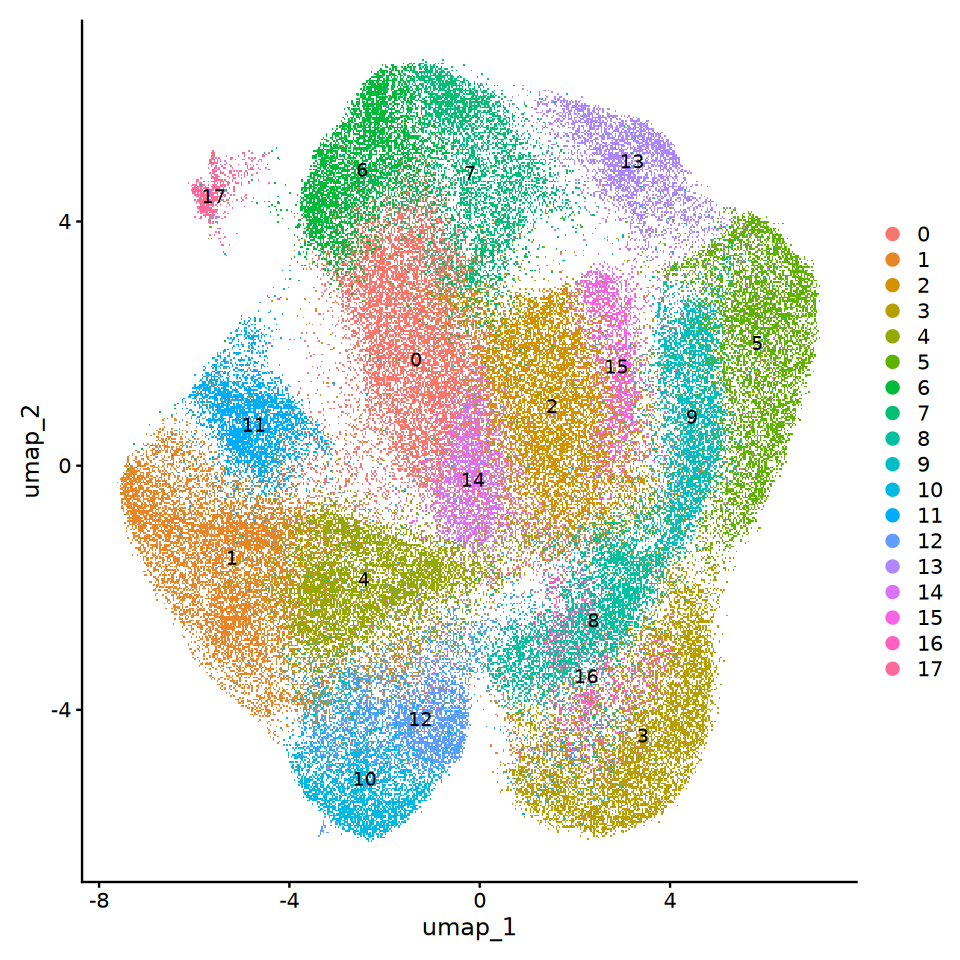

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



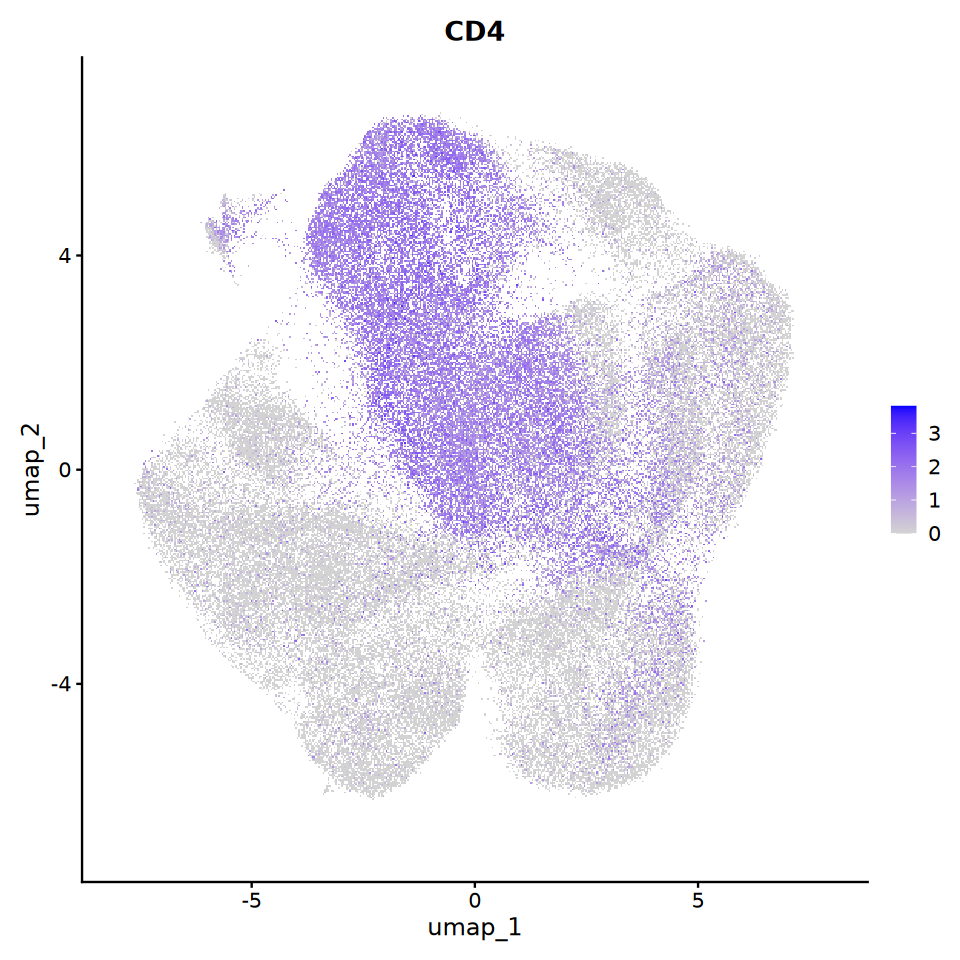

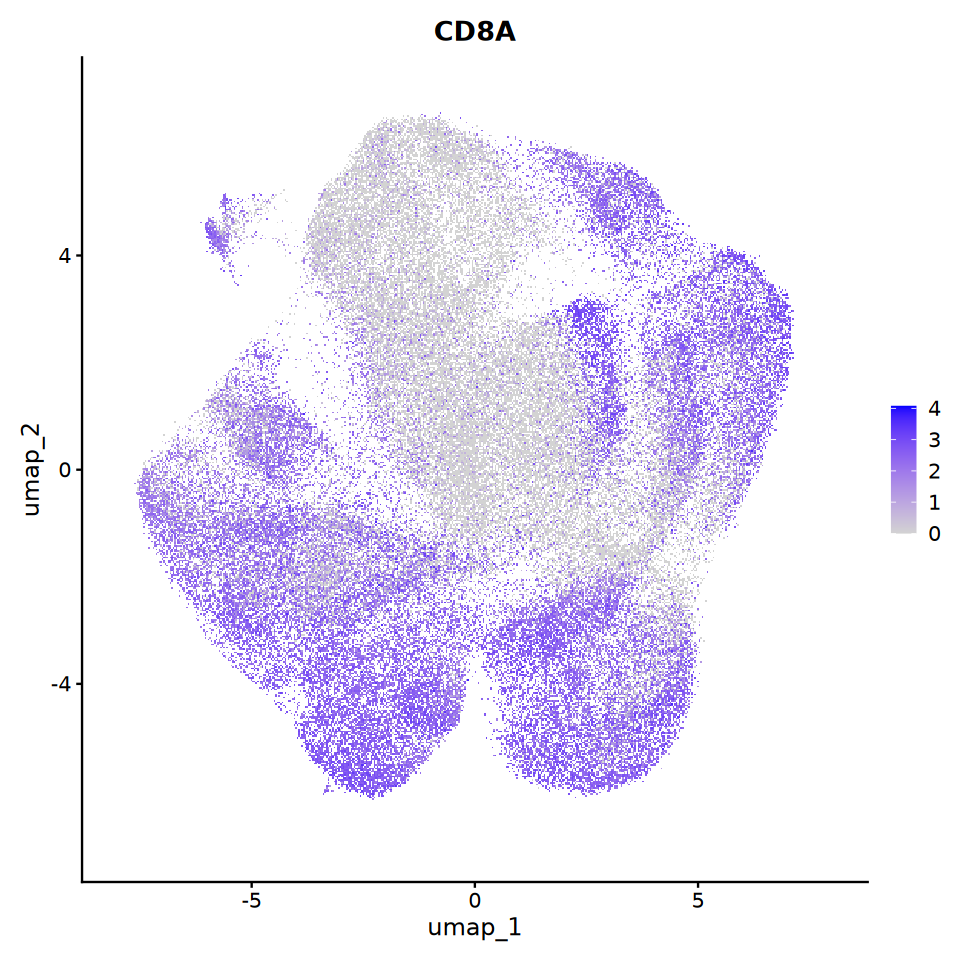

In [10]:
options(repr.plot.width = 8, repr.plot.height = 8)
DimPlot(prolif, label = TRUE)
FeaturePlot(prolif, features = 'CD4')
FeaturePlot(prolif, features = 'CD8A')

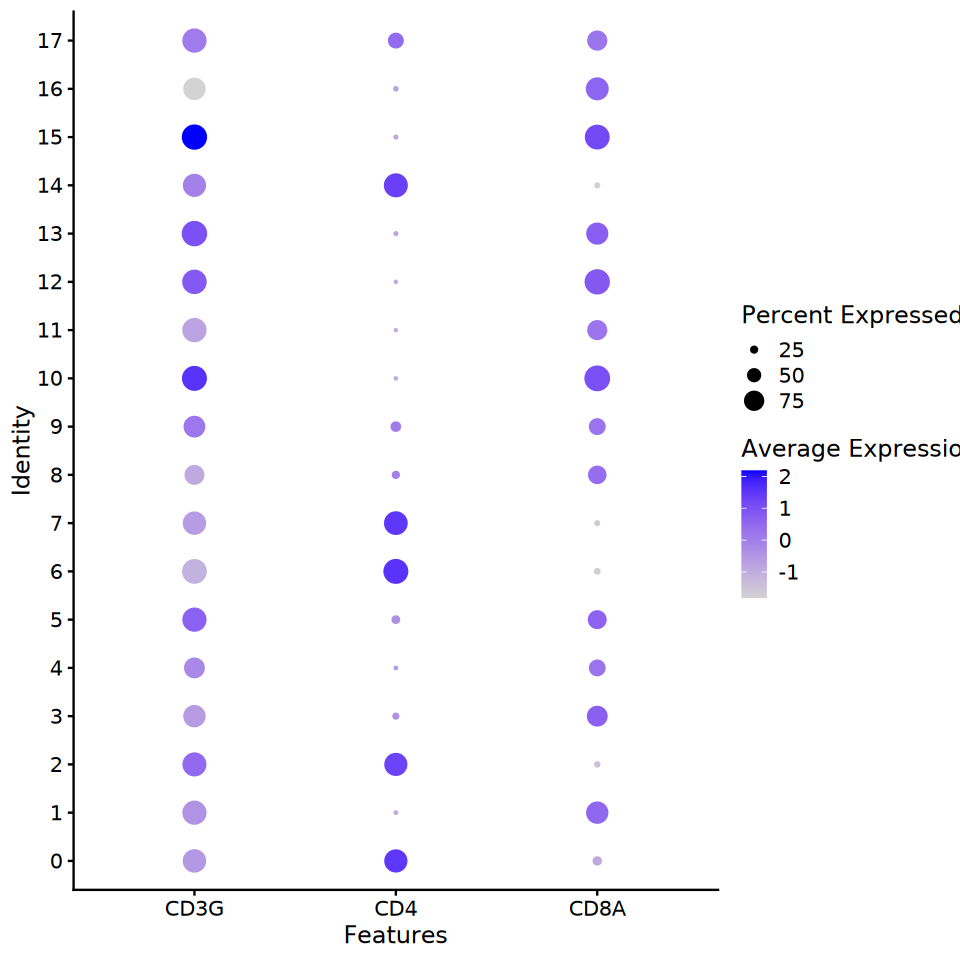

In [11]:
DotPlot(prolif, features = c('CD3G','CD4','CD8A'))

In [12]:
prolif <- SetIdent(prolif, value = 'RNA_snn_res.0.8')
prolif <- RenameIdents(prolif, 
                       '0' = 'Proliferating CD4 T cell',
                       '1' = 'Proliferating CD8 T cell', 
                       '2' = 'Proliferating CD4 T cell', 
                       '3' = 'Proliferating CD8 T cell',
                       '4' = 'Proliferating CD8 T cell',
                       '5' = 'Proliferating CD8 T cell',
                       '6' = 'Proliferating CD4 T cell',
                       '7' = 'Proliferating CD4 T cell',
                       '8' = 'Proliferating CD8 T cell',
                       '9' = 'Proliferating CD8 T cell', 
                       '10' = 'Proliferating CD8 T cell', 
                       '11' = 'Proliferating CD8 T cell', 
                       '12' = 'Proliferating CD8 T cell',
                       '13' = 'Proliferating CD8 T cell',
                       '14' = 'Proliferating CD4 T cell',
                       '15' = 'Proliferating CD8 T cell',
                       '16' = 'Proliferating CD8 T cell',
                       '17' = 'Proliferating DP T cell')
prolif$AIFI_PBMC.Flex_L2_updated <- Idents(prolif)

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Warning message:
“Scaling data with a low number of groups may produce misleading results”


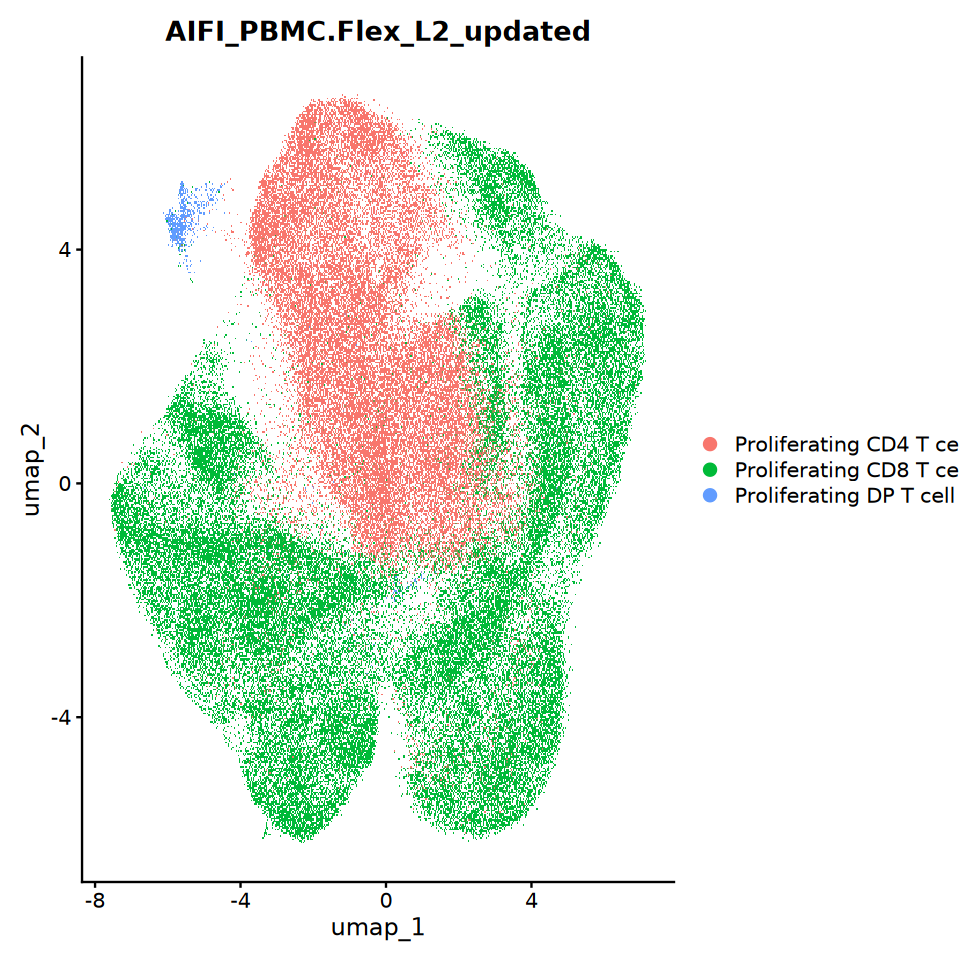

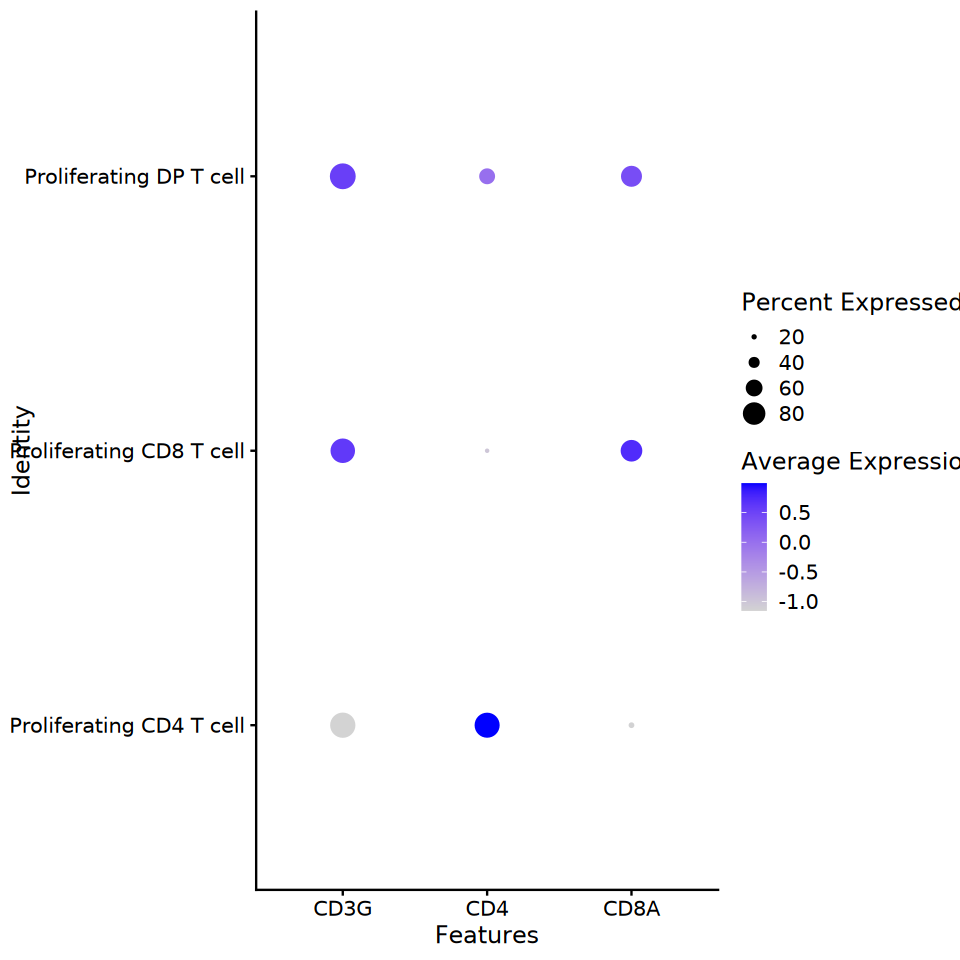

In [13]:
DimPlot(prolif, group.by = 'AIFI_PBMC.Flex_L2_updated')
DotPlot(prolif, features = c('CD3G','CD4','CD8A'), group.by = 'AIFI_PBMC.Flex_L2_updated')

In [14]:
non_prolif <- subset(pep_neg, AIFI_PBMC.Flex_L2 != 'Proliferating T cell')

In [15]:
non_prolif$AIFI_PBMC.Flex_L2_updated <- non_prolif$AIFI_PBMC.Flex_L2

In [16]:
pep_neg_updated <- merge(non_prolif, prolif)

In [17]:
saveRDS(pep_neg_updated, 'pep_neg_updated.rds')

# Cell Type changes over time (SuppFig4a)

In [66]:
l2_df <- pep_neg_updated@meta.data %>%
    subset(AIFI_PBMC.Flex_L2_updated %in% c('Naive CD4 T cell','Memory CD4 T cell','Treg',
           'Proliferating CD4 T cell',
           'Naive CD8 T cell','Memory CD8 T cell',
           'Proliferating CD8 T cell')) %>%
    filter(Peptide != 'Pep+') %>%
    dplyr::group_by(Culture, AIFI_PBMC.Flex_L2_updated, Day) %>%
    dplyr::summarise(count = n()) %>%
    dplyr::group_by(Culture, Day) %>%
    dplyr::mutate(percentage = count / sum(count)*100)

`summarise()` has grouped output by 'Culture', 'AIFI_PBMC.Flex_L2_updated'. You
can override using the `.groups` argument.


In [67]:
alluvial_df_il4 <- l2_df %>%
  filter(Culture %in% c('NA', 'IL4_IL7')) %>%
  mutate(Day = factor(Day, levels = c('Day_0', 'Day_4', 'Day_7', 'Day_10')),
         AIFI_PBMC.Flex_L2_updated = factor(AIFI_PBMC.Flex_L2_updated, levels = c(
           'Naive CD4 T cell','Memory CD4 T cell','Treg',
           'Proliferating CD4 T cell',
           'Naive CD8 T cell','Memory CD8 T cell',
           'Proliferating CD8 T cell')))

In [68]:
library(ggsci)

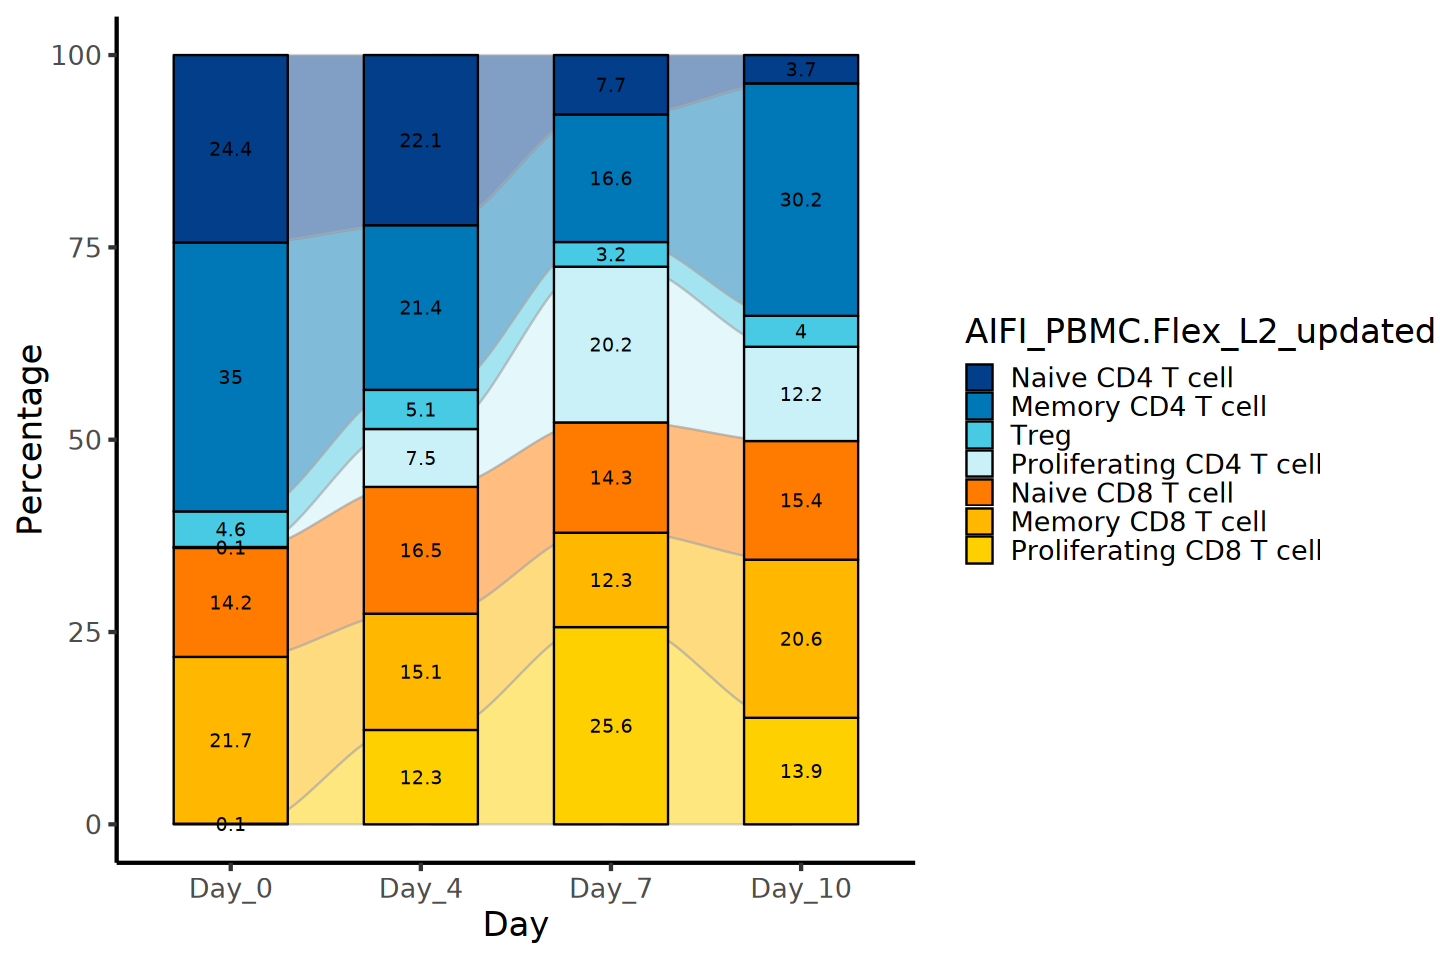

In [69]:
options(repr.plot.width = 12, repr.plot.height = 8)
ggplot(alluvial_df_il4,
       aes(x = Day,
           stratum = AIFI_PBMC.Flex_L2_updated,
           alluvium = AIFI_PBMC.Flex_L2_updated,
           y = percentage,
           fill = AIFI_PBMC.Flex_L2_updated,
           label = round(percentage, 1))) +
  geom_flow(stat = "alluvium", lode.guidance = "frontback", color = "darkgray", width=0.1) +
  geom_stratum(width=0.6) +
  geom_text(stat = "stratum", size = 4) +
  scale_fill_manual(values = c('#023e8a','#0077b6','#48cae4','#caf0f8','#ff7b00','#ffb700','#ffd000')) +
  # facet_grid(cols = vars(Donor)) +
  theme_classic(base_size = 20) +
  ylab("Percentage")

In [70]:
# Open the PDF graphics device
pdf("plots/Fig1e_IL4_Stacked_Barplot.pdf", width = 12, height = 8) # You can specify width and height in inches

# Create your plot
ggplot(alluvial_df_il4,
       aes(x = Day,
           stratum = AIFI_PBMC.Flex_L2_updated,
           alluvium = AIFI_PBMC.Flex_L2_updated,
           y = percentage,
           fill = AIFI_PBMC.Flex_L2_updated,
           label = round(percentage, 1))) +
  geom_flow(stat = "alluvium", lode.guidance = "frontback", color = "darkgray", width=0.1) +
  geom_stratum(width=0.6) +
  geom_text(stat = "stratum", size = 4) +
  scale_fill_manual(values = c('#023e8a','#0077b6','#48cae4','#caf0f8','#ff7b00','#ffb700','#ffd000')) +
  # facet_grid(cols = vars(Donor)) +
  theme_classic(base_size = 20) +
  ylab("Percentage")

# Close the graphics device to save the plot
dev.off()

pdf 
  2

In [71]:
alluvial_df_il15 <- l2_df %>%
  filter(Culture %in% c('NA', 'IL7_IL15')) %>%
  mutate(Day = factor(Day, levels = c('Day_0', 'Day_4', 'Day_7', 'Day_10')),
         AIFI_PBMC.Flex_L2_updated = factor(AIFI_PBMC.Flex_L2_updated, levels = c(
           'Naive CD4 T cell','Memory CD4 T cell','Treg',
           'Proliferating CD4 T cell',
           'Naive CD8 T cell','Memory CD8 T cell',
           'Proliferating CD8 T cell')))

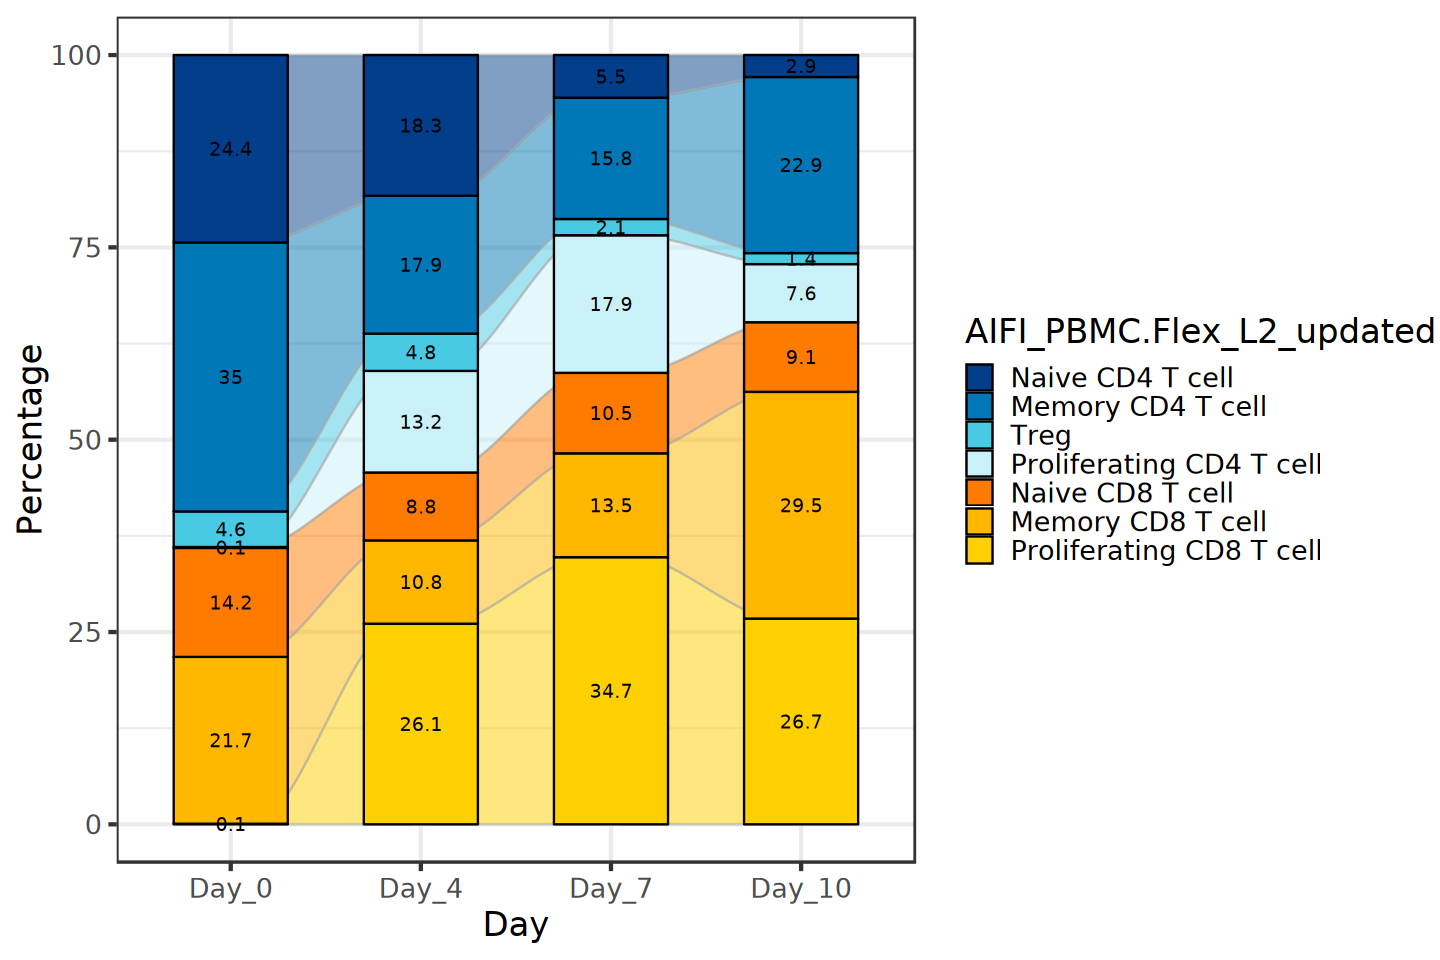

In [72]:
options(repr.plot.width = 12, repr.plot.height = 8)
ggplot(alluvial_df_il15,
       aes(x = Day,
           stratum = AIFI_PBMC.Flex_L2_updated,
           alluvium = AIFI_PBMC.Flex_L2_updated,
           y = percentage,
           fill = AIFI_PBMC.Flex_L2_updated,
           label = round(percentage, 1))) +
  geom_flow(stat = "alluvium", lode.guidance = "frontback", color = "darkgray", width=0.1) +
  geom_stratum(width=0.6) +
  geom_text(stat = "stratum", size = 4) +
  scale_fill_manual(values = c('#023e8a','#0077b6','#48cae4','#caf0f8','#ff7b00','#ffb700','#ffd000')) +
  # facet_grid(cols = vars(Donor)) +
  theme_bw(base_size = 20) +
  ylab("Percentage")

In [73]:
# Open the PDF graphics device
pdf("plots/Fig1e_IL15_Stacked_Barplot.pdf", width = 12, height = 8) # You can specify width and height in inches

# Create your plot
ggplot(alluvial_df_il15,
       aes(x = Day,
           stratum = AIFI_PBMC.Flex_L2_updated,
           alluvium = AIFI_PBMC.Flex_L2_updated,
           y = percentage,
           fill = AIFI_PBMC.Flex_L2_updated,
           label = round(percentage, 1))) +
  geom_flow(stat = "alluvium", lode.guidance = "frontback", color = "darkgray", width=0.1) +
  geom_stratum(width=0.6) +
  geom_text(stat = "stratum", size = 4) +
  scale_fill_manual(values = c('#023e8a','#0077b6','#48cae4','#caf0f8','#ff7b00','#ffb700','#ffd000')) +
  # facet_grid(cols = vars(Donor)) +
  theme_bw(base_size = 20) +
  ylab("Percentage")

# Close the graphics device to save the plot
dev.off()

pdf 
  2

# Gene Expression (SuppFig4a)

In [42]:
pep_neg_updated <- NormalizeData(pep_neg_updated)

Normalizing layer: counts.1

Normalizing layer: counts.2



In [59]:
ribbon_plots <- function(so_input, gene){

    # extract gene expression
    exp_df <- FetchData(so_input, vars = c(gene,'Day','AIFI_PBMC.Flex_L2_updated','Culture'))
    exp_df <- subset(exp_df, 
                    AIFI_PBMC.Flex_L2_updated %in% 
                    c('Naive CD4 T cell','Memory CD4 T cell','Treg',
           'Proliferating CD4 T cell',
           'Naive CD8 T cell','Memory CD8 T cell',
           'Proliferating CD8 T cell'))

    # explicit column names
    colnames(exp_df) <- c('Expression','Day','AIFI_PBMC.Flex_L2_updated','Culture')
    exp_df$Day <- factor(exp_df$Day, levels = c('Day_0','Day_4','Day_7','Day_10'))
    exp_df$AIFI_PBMC.Flex_L2_updated <- factor(exp_df$AIFI_PBMC.Flex_L2_updated, levels = c('Naive CD4 T cell','Memory CD4 T cell','Treg',
           'Proliferating CD4 T cell',
           'Naive CD8 T cell','Memory CD8 T cell',
           'Proliferating CD8 T cell'))
    

    # split by culture
    exp_df_il4 <- subset(exp_df, Culture != 'IL7_IL15')
    exp_df_il15 <- subset(exp_df, Culture != 'IL4_IL7')
    
   # summarise
    summary_exp_df_il4 <- exp_df_il4 %>%
      group_by(AIFI_PBMC.Flex_L2_updated, Day) %>%
      summarise(
        mean_expr = mean(Expression),
        q25 = quantile(Expression, 0.25),
        q75 = quantile(Expression, 0.75),
        .groups = "drop"
      )

    summary_exp_df_il15 <- exp_df_il15 %>%
      group_by(AIFI_PBMC.Flex_L2_updated, Day) %>%
      summarise(
        mean_expr = mean(Expression),
        q25 = quantile(Expression, 0.25),
        q75 = quantile(Expression, 0.75),
        .groups = "drop"
      )

    # get maximum
    max_exp <- max(max(summary_exp_df_il4$mean_expr),max(summary_exp_df_il15$mean_expr))

    # Plot
    p1 <- ggplot(summary_exp_df_il4, aes(x = Day, y = mean_expr, color = AIFI_PBMC.Flex_L2_updated, group = AIFI_PBMC.Flex_L2_updated)) +
      geom_line(size = 1) +  # mean line per cell type
      # geom_ribbon(aes(ymin = q25, ymax = q75, fill = AIFI_PBMC.Flex_L2_updated), alpha = 0.2, color = NA) +  # quantile spread
      theme_classic(base_size = 15) + ylim(0,max_exp+0.2) +
      scale_color_manual(values = c('#023e8a','#0077b6','#48cae4','#caf0f8','#ff7b00','#ffb700','#ffd000')) +
      labs(
        title = paste("Average Expression of",gene, "over Time in IL4"),
        x = "Day",
        y = "Expression",
        color = "Cell Type",
        fill = "Cell Type"
      ) +
      theme(
        plot.title = element_text(hjust = 0.5)
      )
    p2 <- ggplot(summary_exp_df_il15, aes(x = Day, y = mean_expr, color = AIFI_PBMC.Flex_L2_updated, group = AIFI_PBMC.Flex_L2_updated)) +
      geom_line(size = 1) +  # mean line per cell type
      # geom_ribbon(aes(ymin = q25, ymax = q75, fill = AIFI_PBMC.Flex_L2_updated), alpha = 0.2, color = NA) +  # quantile spread
      theme_classic(base_size = 15) + ylim(0,max_exp+0.2) +
      scale_color_manual(values = c('#023e8a','#0077b6','#48cae4','#caf0f8','#ff7b00','#ffb700','#ffd000')) +
      labs(
        title = paste("Average Expression of",gene, "over Time in IL15"),
        x = "Day",
        y = "Average Expression",
        color = "Cell Type",
        fill = "Cell Type"
      ) +
      theme(
        plot.title = element_text(hjust = 0.5)
      )
    cowplot::plot_grid(p1,p2,nrow=2)
}

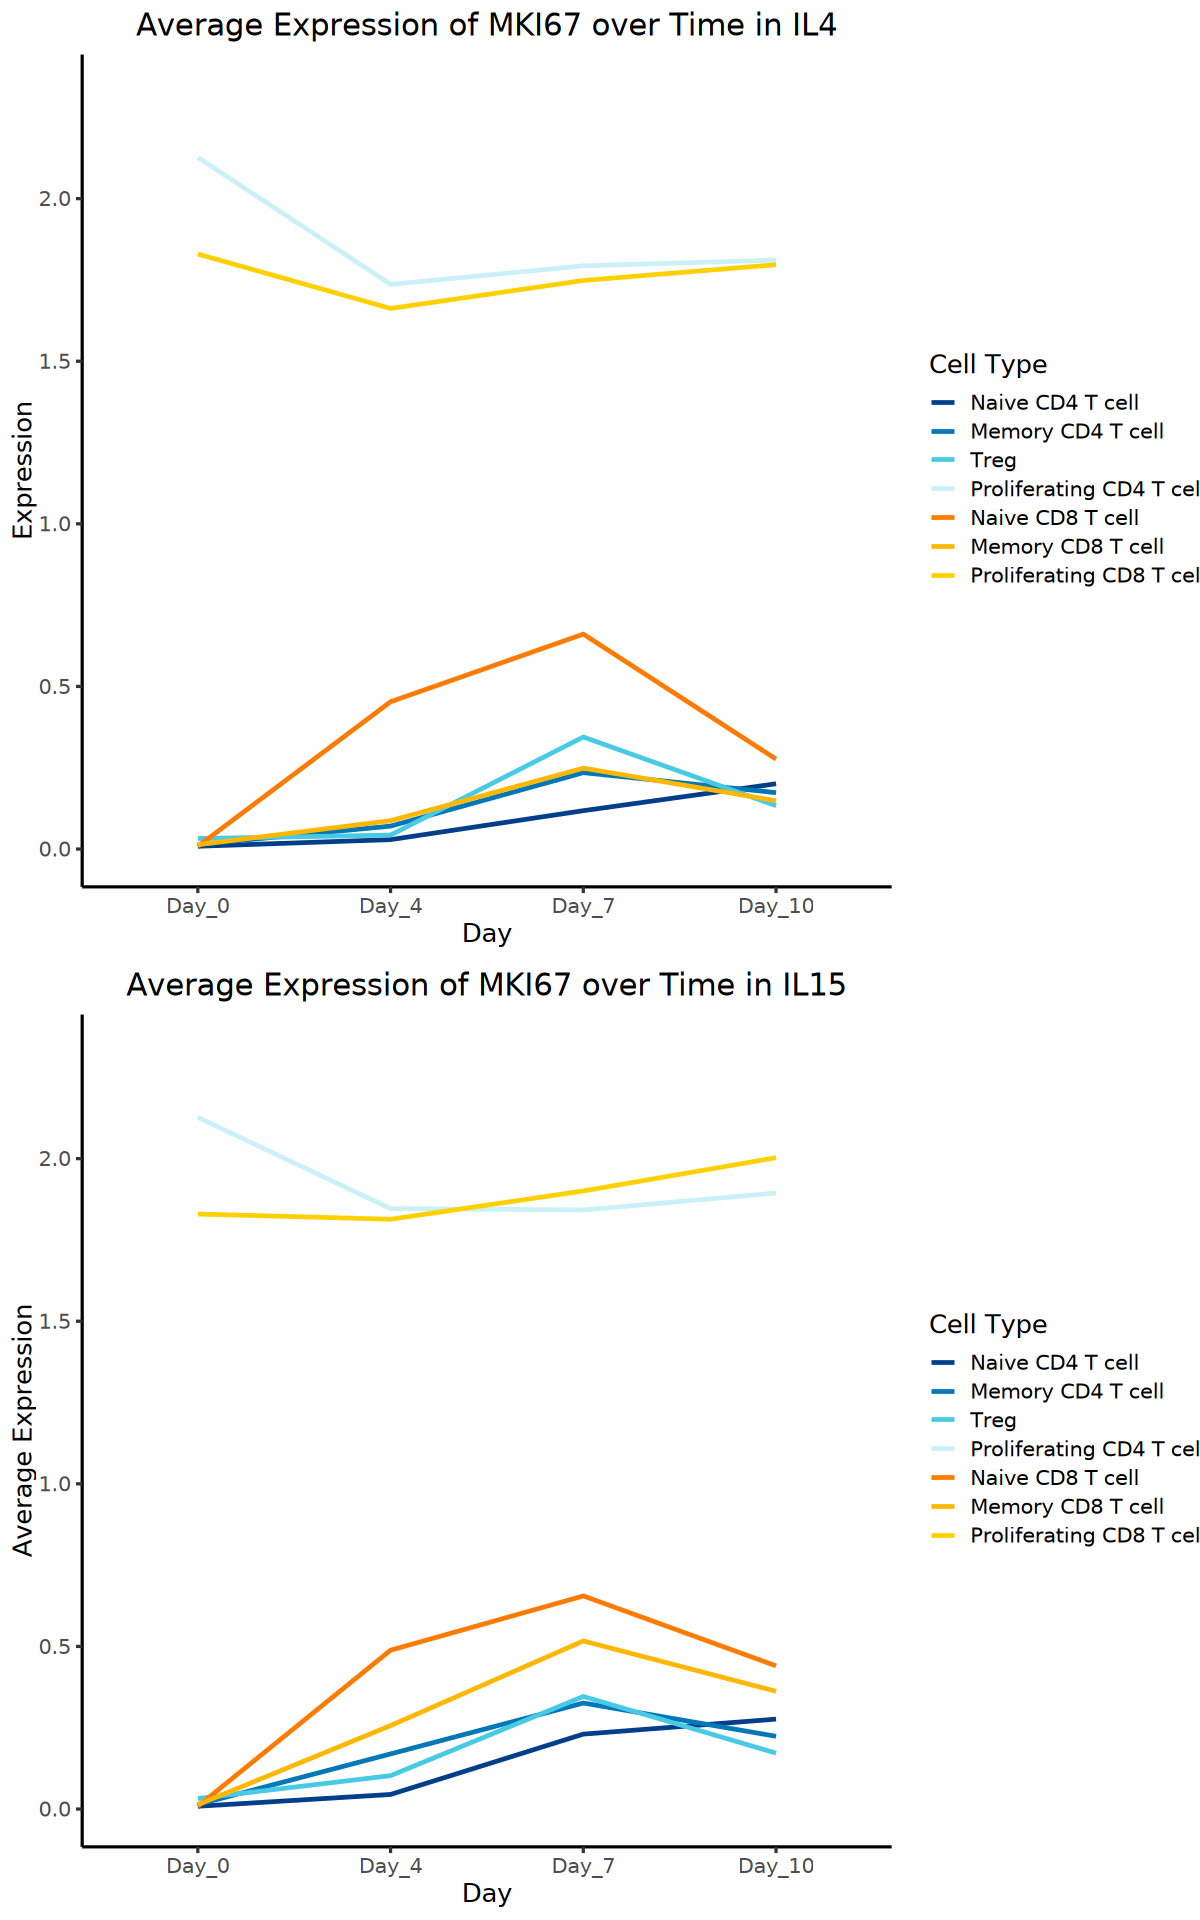

In [60]:
options(repr.plot.width = 10, repr.plot.height = 16)
ribbon_plots(so_input = pep_neg_updated, gene = 'MKI67')

In [61]:
# Open the PDF graphics device
pdf("plots/Fig1e_MKI67_exp.pdf", width = 10, height = 16) # You can specify width and height in inches

# Create your plot
ribbon_plots(so_input = pep_neg_updated, gene = 'MKI67')

# Close the graphics device to save the plot
dev.off()

pdf 
  2

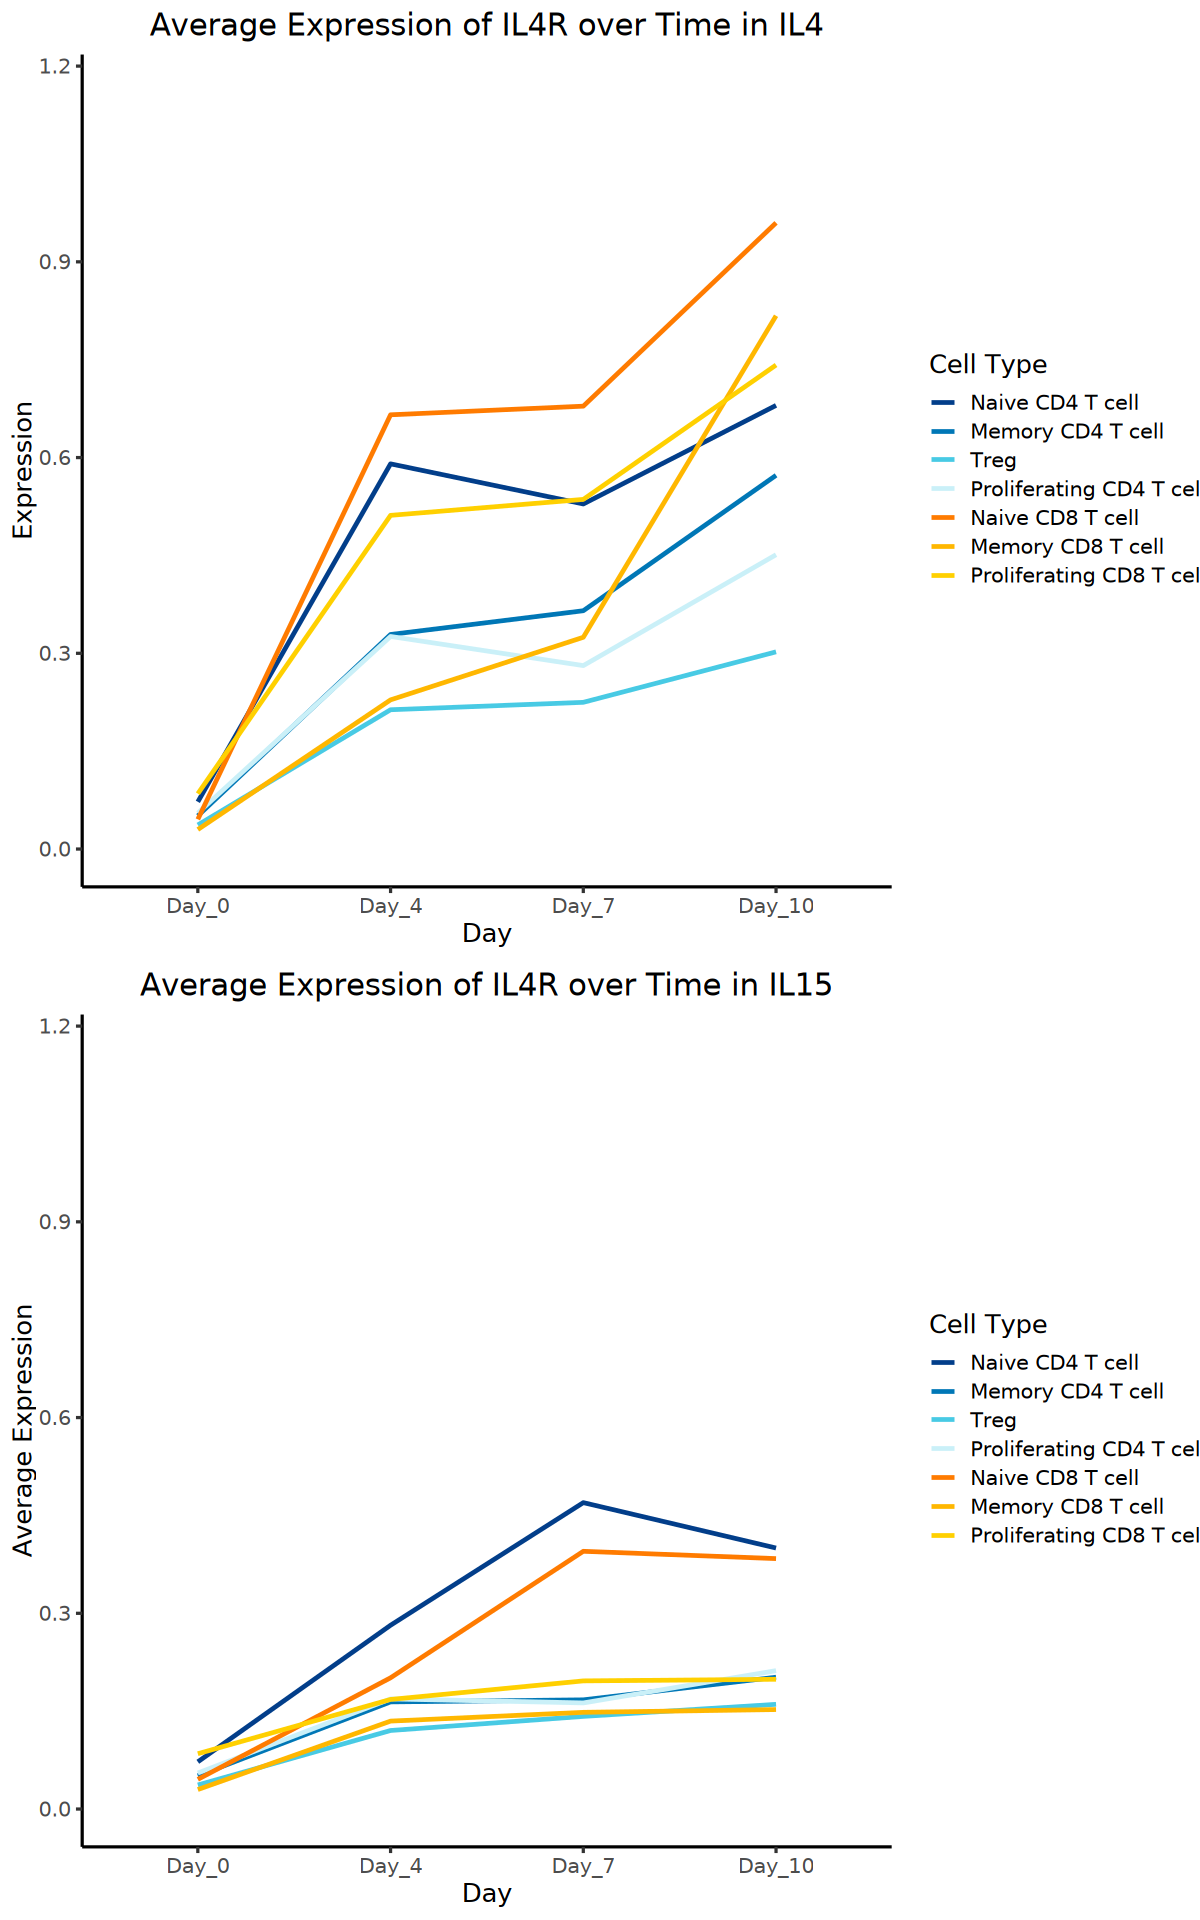

In [62]:
ribbon_plots(so_input = pep_neg_updated, gene = 'IL4R')

In [63]:
# Open the PDF graphics device
pdf("plots/Fig1e_IL4R_exp.pdf", width = 10, height = 16) # You can specify width and height in inches

# Create your plot
ribbon_plots(so_input = pep_neg_updated, gene = 'IL4R')

# Close the graphics device to save the plot
dev.off()

pdf 
  2

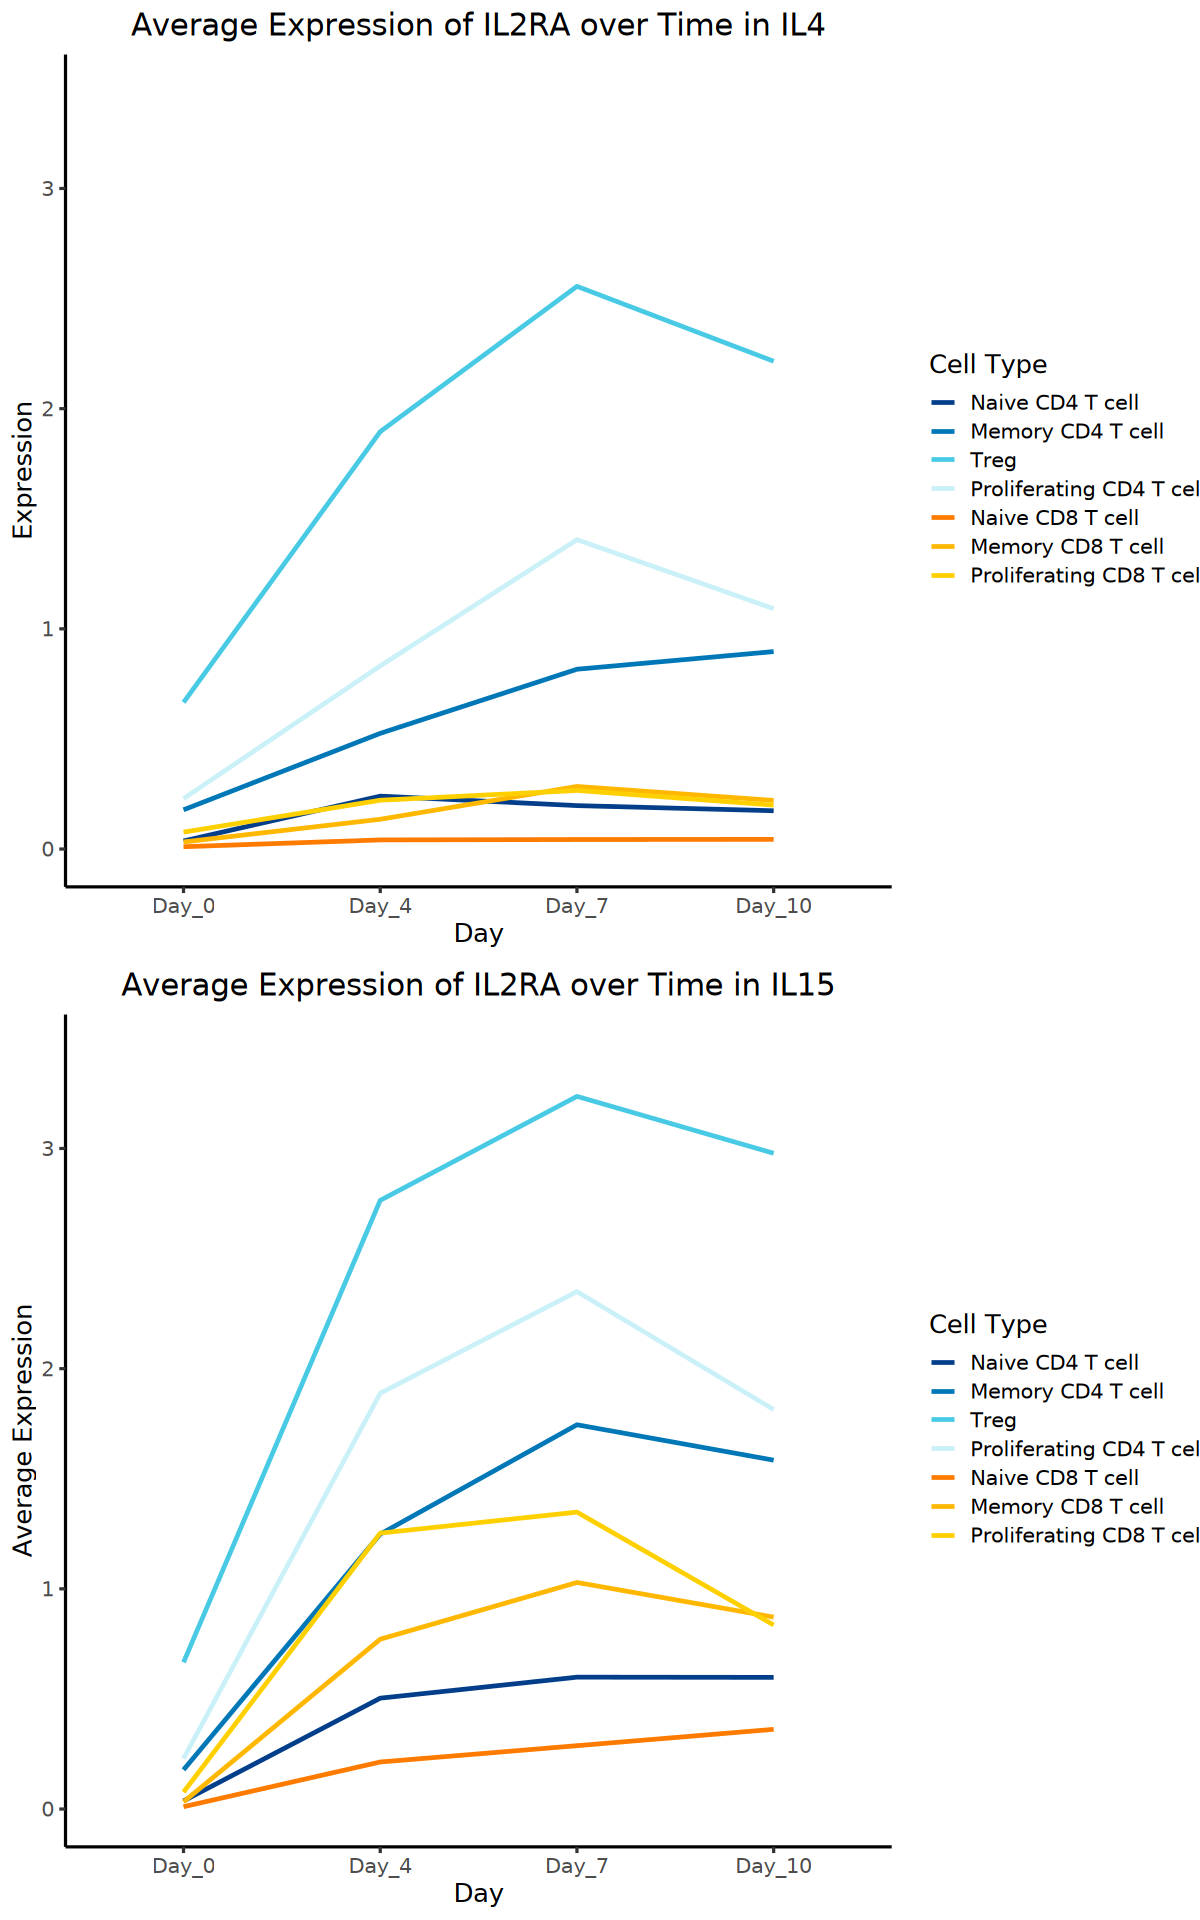

In [64]:
ribbon_plots(so_input = pep_neg_updated, gene = 'IL2RA')

In [65]:
# Open the PDF graphics device
pdf("plots/Fig1e_IL2RA_exp.pdf", width = 10, height = 16) # You can specify width and height in inches

# Create your plot
ribbon_plots(so_input = pep_neg_updated, gene = 'IL2RA')

# Close the graphics device to save the plot
dev.off()

pdf 
  2

# TCR Capture (SuppFig4b)

In [21]:
library(stringr)

Warning message:
“package ‘stringr’ was built under R version 4.4.3”


In [19]:
pep_neg_updated$CTgene_archive <- pep_neg_updated$CTgene

In [22]:
pep_neg_updated@meta.data <- pep_neg_updated@meta.data %>%
  mutate(
    CTgene = str_remove_all(CTgene_archive, "\\*[A-Za-z0-9]+\\([0-9.]+\\)")
  )

In [23]:
pep_neg_updated@meta.data <- pep_neg_updated@meta.data %>%
  mutate(clone_type = case_when(
    # Case 1: Total NA (either the logical NA or the literal "NA" string)
    is.na(CTgene) | CTgene == "NA" ~ "No clone",
    
    # Case 2: Starts with NA_ (meaning Alpha is missing)
    str_detect(CTgene, "^NA_")     ~ "TRB",
    
    # Case 3: Ends with _NA (meaning Beta is missing)
    str_detect(CTgene, "_NA$")     ~ "TRA",
    
    # Case 4: Everything else (both parts have characters)
    TRUE                           ~ "Paired"
  ))

In [25]:
paired_meta <- pep_neg_updated@meta.data %>%
    subset(AIFI_PBMC.Flex_L2_updated %in% 
           c('Naive CD4 T cell','Memory CD4 T cell','Treg',
           'Proliferating CD4 T cell',
           'Naive CD8 T cell','Memory CD8 T cell',
           'Proliferating CD8 T cell')) %>%
    group_by(Day, Culture, AIFI_PBMC.Flex_L2_updated, clone_type) %>%
    summarise(count = n()) %>% 
    group_by(Day, Culture, AIFI_PBMC.Flex_L2_updated) %>%
    mutate(percentage_paired = count / sum(count) * 100) 

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by Day, Culture, AIFI_PBMC.Flex_L2_updated,
  and clone_type.
ℹ Output is grouped by Day, Culture, and AIFI_PBMC.Flex_L2_updated.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(Day, Culture, AIFI_PBMC.Flex_L2_updated, clone_type))`
  for per-operation grouping (`?dplyr::dplyr_by`) instead.


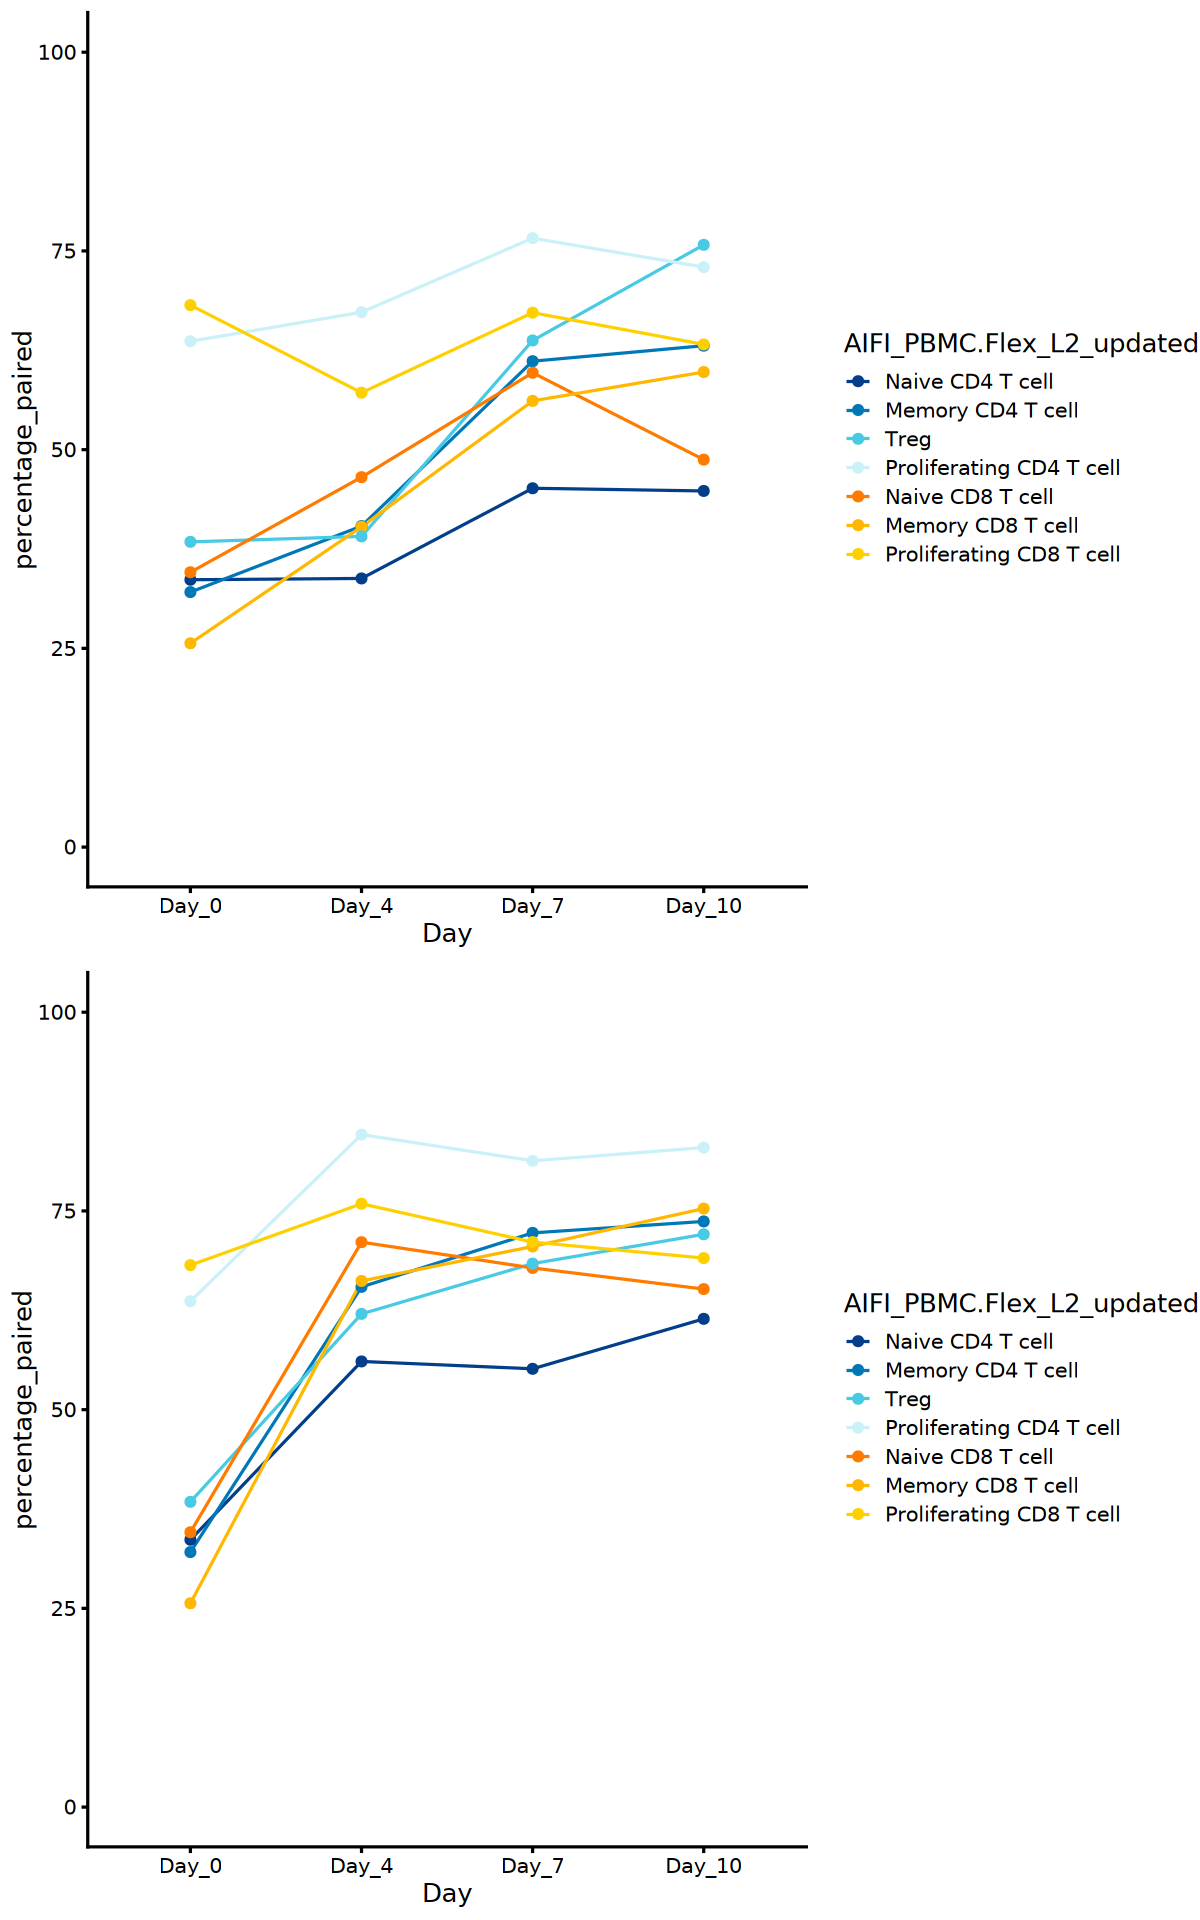

In [28]:
options(repr.plot.width = 10, repr.plot.height = 16)
p1 <- paired_meta %>%
    filter(Culture != 'IL7_IL15') %>%
    mutate(Day = factor(Day, levels = c('Day_0','Day_4','Day_7','Day_10'))) %>%
    mutate(AIFI_PBMC.Flex_L2_updated = factor(AIFI_PBMC.Flex_L2_updated, levels = c('Naive CD4 T cell','Memory CD4 T cell','Treg',
           'Proliferating CD4 T cell',
           'Naive CD8 T cell','Memory CD8 T cell',
           'Proliferating CD8 T cell'))) %>%
    filter(clone_type == 'Paired') %>%
    ggplot(aes(x=Day, y=percentage_paired, color=AIFI_PBMC.Flex_L2_updated, group=AIFI_PBMC.Flex_L2_updated)) + 
        geom_line() + geom_point() + theme_classic(base_size = 15) +  ylim(0,100) +
        scale_color_manual(values = c('#023e8a','#0077b6','#48cae4','#caf0f8','#ff7b00','#ffb700','#ffd000'))
p2 <- paired_meta %>%
    filter(Culture != 'IL4_IL7') %>%
    mutate(Day = factor(Day, levels = c('Day_0','Day_4','Day_7','Day_10'))) %>%
    mutate(AIFI_PBMC.Flex_L2_updated = factor(AIFI_PBMC.Flex_L2_updated, levels = c('Naive CD4 T cell','Memory CD4 T cell','Treg',
           'Proliferating CD4 T cell',
           'Naive CD8 T cell','Memory CD8 T cell',
           'Proliferating CD8 T cell'))) %>%
    filter(clone_type == 'Paired') %>%
    ggplot(aes(x=Day, y=percentage_paired, color=AIFI_PBMC.Flex_L2_updated, group=AIFI_PBMC.Flex_L2_updated)) + 
        geom_line() + geom_point() + theme_classic(base_size = 15) + ylim(0,100) +
        scale_color_manual(values = c('#023e8a','#0077b6','#48cae4','#caf0f8','#ff7b00','#ffb700','#ffd000'))
cowplot::plot_grid(p1,p2,ncol=1)

In [55]:
# Open the PDF graphics device
pdf("plots/Supp_Fig4_TCR_performance.pdf", width = 10, height = 16) # You can specify width and height in inches

# Create your plot
cowplot::plot_grid(p1,p2,ncol=1)

# Close the graphics device to save the plot
dev.off()

pdf 
  2